# SAC-QUBO — 负定矩阵 $A = -K$
## $|A| = K,\quad \text{sign}(A) = -I,\quad r_* = -b$
$E(x) = \frac{1}{2}x^T K x - x^T(-b) = \frac{1}{2}x^T K x + x^T b$
SAC 退化: 翻转符号 → $\kappa(|A|) = \kappa(K) \ll \kappa(K^2)$

In [5]:
import numpy as np, matplotlib.pyplot as plt, time, warnings, json, os
warnings.filterwarnings('ignore')
import kaiwu as kw
kw.common.CheckpointManager.save_dir = '/tmp'

Lx, Ly = 3.0, 2.0
Nx, Ny = 10, 8          # 更大网格: 48 内部节点 (单次求解 8×8 仅 36)
BIT_WIDTH = 8
OUTPUT_DIR = 'D:/QPDE/fuck/output_energy_negdef'
os.makedirs(OUTPUT_DIR, exist_ok=True)
TASK_NAME = 'energy_negdef'
METHOD = 'energy_negdef'
print(f'网格: {Nx}×{Ny}, 位宽: {BIT_WIDTH}')


网格: 10×8, 位宽: 8


In [6]:
# ===== 网格 =====
x = np.linspace(0, Lx, Nx); y = np.linspace(0, Ly, Ny)
X, Y = np.meshgrid(x, y, indexing='ij')
nodes = np.column_stack([X.ravel(), Y.ravel()])
n_nodes = Nx * Ny
boundary = (X.ravel()==0) | (X.ravel()==Lx) | (Y.ravel()==0) | (Y.ravel()==Ly)
internal = ~boundary
n_i = internal.sum()
print(f'总节点: {n_nodes}, 内部: {n_i}, QUBO变量: {n_i * BIT_WIDTH}')


总节点: 80, 内部: 48, QUBO变量: 384


In [7]:
# ===== 解析解 & 源项 =====
def u_exact(x, y):
    return x * y * np.cos(2*np.pi*x/3.0)

def source_term(x, y):
    u_xx = -(2*np.pi/3.0)**2 * x * y * np.cos(2*np.pi*x/3.0) - (4*np.pi/3.0) * y * np.sin(2*np.pi*x/3.0)
    return -(u_xx + 0.0)

u_exact_all = np.array([u_exact(xi, yi) for xi, yi in nodes])
print(f'精确解: [{u_exact_all.min():.4f}, {u_exact_all.max():.4f}]')


精确解: [-3.1323, 6.0000]


In [8]:
# ===== FEM 装配 (5-point FD) =====
hx = Lx/(Nx-1); hy = Ly/(Ny-1)
K = np.zeros((n_nodes, n_nodes)); F = np.zeros(n_nodes)
for i in range(1, Nx-1):
    for j in range(1, Ny-1):
        k = i*Ny + j
        K[k,k] = 2/hx**2 + 2/hy**2
        K[k, k-1] = K[k, k+1] = -1/hy**2
        K[k, k-Ny] = K[k, k+Ny] = -1/hx**2
        F[k] = source_term(nodes[k,0], nodes[k,1])
print(f'K: {K.shape}, cond(K)={np.linalg.cond(K):.2e}')


K: (80, 80), cond(K)=inf


In [9]:
# ===== Dirichlet BC 归约 =====
idx_map = -np.ones(n_nodes, dtype=int)
idx_map[internal] = np.arange(n_i)
K_ii = np.zeros((n_i, n_i)); rhs = np.zeros(n_i)
for gi in np.where(internal)[0]:
    ki = idx_map[gi]; K_ii[ki, ki] = K[gi, gi]; rhs[ki] = F[gi]
    for gj in [gi-1, gi+1, gi-Ny, gi+Ny]:
        if 0 <= gj < n_nodes:
            if internal[gj]: K_ii[ki, idx_map[gj]] = K[gi, gj]
            else: rhs[ki] -= K[gi, gj] * u_exact(nodes[gj,0], nodes[gj,1])
u_poisson = np.linalg.solve(K_ii, rhs)             # 原 Poisson 解 (仅参考)
print(f'K_ii cond: {np.linalg.cond(K_ii):.2f}')


K_ii cond: 23.20


In [10]:
# ===== 构造负定矩阵 A = -K =====
A_mat = -K_ii
b_vec = rhs.copy()
eigvals_A = np.linalg.eigvalsh(A_mat)
print(f'A = -K_ii, 特征值全负: [{eigvals_A.max():.3f}, {eigvals_A.min():.3f}]')

# ===== SAC: |A| = K, sign(A) = -I → r_* = -b =====
absA = K_ii.copy()         # |-K| = K  (无需特征分解!)
r_sac = -b_vec               # sign(-K)·b = -b
print(f'|A| = K (直接使用), κ(|A|) = {np.linalg.cond(absA):.1f}')
print(f'SAC 优势: κ(|A|)={np.linalg.cond(absA):.0f} vs κ(A²)={np.linalg.cond(K_ii@K_ii):.0f}')
print(f'条件数降低 {np.linalg.cond(K_ii@K_ii)/np.linalg.cond(K_ii):.0f}×')


A = -K_ii, 特征值全负: [-3.512, -81.488]
|A| = K (直接使用), κ(|A|) = 23.2
SAC 优势: κ(|A|)=23 vs κ(A²)=538
条件数降低 23×


In [11]:
# ===== 参考解: A x = b 的精确解 =====
u_ref_A = np.linalg.solve(A_mat, b_vec)
print(f'A⁻¹b: [{u_ref_A.min():.4f}, {u_ref_A.max():.4f}]')


A⁻¹b: [-3.4936, 2.7418]


In [12]:
# ===== 编码边界 (基于 u_ref_A) =====
margin = 0.5; rng = max(u_ref_A.max()-u_ref_A.min(), 0.1)
lb = u_ref_A.min() - margin*rng; ub = u_ref_A.max() + margin*rng
print(f'编码界: [{lb:.4f}, {ub:.4f}]')


编码界: [-6.6113, 5.8594]


In [13]:
def build_sac_qubo(A_abs, r_sac, bw, lb, ub):
    '''SAC 能量 QUBO: min ½xᵀ|A|x - xᵀr_sac
    Q = ½|A|⊗(ssᵀ) + diag(Mᵀ(|A|c - r_sac))'''
    n = A_abs.shape[0]; nvar = n*bw
    scale = (ub-lb)/(2**bw-1)
    s = scale * np.array([2**k for k in range(bw)]); ssT = np.outer(s,s)
    c = lb * np.ones(n); w = A_abs@c - r_sac
    Q = np.zeros((nvar, nvar))
    for i in range(n):
        for j in range(i, n):
            aij = A_abs[i,j]
            if abs(aij) < 1e-15: continue
            ri, rj = i*bw, j*bw; blk = 0.5*aij*ssT
            Q[ri:ri+bw, rj:rj+bw] += blk
            if i != j: Q[rj:rj+bw, ri:ri+bw] += blk.T
    for i in range(n): Q[i*bw:(i+1)*bw, i*bw:(i+1)*bw] += np.diag(w[i]*s)
    return Q.astype(np.float32), nvar, scale


In [14]:
def decode(z_best, n, bw, scale, lb):
    M = np.zeros((n, n*bw)); s = scale*np.array([2**k for k in range(bw)])
    for i in range(n): M[i, i*bw:(i+1)*bw] = s
    return M@z_best + lb


In [15]:
# ===== SAC-QUBO 构建 (|A| = K, r_sac = -b) =====
Q_float, nvar, scale = build_sac_qubo(absA, r_sac, BIT_WIDTH, lb, ub)
Q_qubo = kw.qubo.adjust_qubo_matrix_precision(Q_float)
print(f'SAC QUBO: {nvar}x{nvar}, 值: [{Q_qubo.min():.0f}, {Q_qubo.max():.0f}]')
print(f'(同正定 Energy-QUBO, 仅右端项符号翻转)')


SAC QUBO: 384x384, 值: [-392, 716]
(同正定 Energy-QUBO, 仅右端项符号翻转)


In [16]:
# ===== CIM 提交 =====
ising_mat, ising_bias = kw.conversion.qubo_matrix_to_ising_matrix(Q_qubo)
vars_ = [f'x[{i}]' for i in range(ising_mat.shape[0])]
model = kw.ising.IsingModel(variables=vars_, ising_matrix=ising_mat, bias=ising_bias)
opt = kw.cim.CIMOptimizer(task_name=TASK_NAME, task_mode='quota')
t0 = time.time()
opt.solve(model.get_matrix())
print(f'已提交, Ising: {ising_mat.shape}')


[2026-05-21 14:25:36] [INFO    ] [kaiwu.cim._optimizer_adapter:7] - Task submit successfully, waiting for data validation. Task name: energy_negdef
已提交, Ising: (385, 385)


In [18]:
# ===== CIM 取回 + 解码 =====
sol = opt.solve(model.get_matrix())
dt = time.time()-t0; print(f'返回: {sol.shape}, 耗时: {dt:.1f}s')

sols_bin = (sol[:,:-1]*sol[:,-1:]+1)/2
energies = np.array([z@Q_qubo@z for z in sols_bin])
z_best = sols_bin[np.argmin(energies)]
u_quantum_i = decode(z_best, n_i, BIT_WIDTH, scale, lb)

u_quantum = np.zeros(n_nodes); u_quantum[internal] = u_quantum_i
for gi in np.where(boundary)[0]: u_quantum[gi] = u_exact(nodes[gi,0], nodes[gi,1])

u_ref_A_all = np.zeros(n_nodes); u_ref_A_all[internal] = u_ref_A
for gi in np.where(boundary)[0]: u_ref_A_all[gi] = u_exact(nodes[gi,0], nodes[gi,1])

rmse_ref = np.sqrt(np.mean((u_quantum_i - u_ref_A)**2))
print(f'最优能量: {energies.min():.1f}')
print(f'RMSE vs A⁻¹b (参考): {rmse_ref:.6e}')
print(f'κ(|A|) = κ(K) = {np.linalg.cond(K_ii):.1f}  (cf. κ(A²) = {np.linalg.cond(K_ii@K_ii):.1f})')


[2026-05-21 14:27:37] [INFO    ] [kaiwu.cim._optimizer_adapter:2] - Task completed: energy_negdef
返回: (10, 385), 耗时: 123.0s
最优能量: -5940.0
RMSE vs A⁻¹b (参考): 8.624428e-01
κ(|A|) = κ(K) = 23.2  (cf. κ(A²) = 538.4)


In [19]:
# ===== 保存 =====
np.save(f'{OUTPUT_DIR}/u_quantum.npy', u_quantum)
np.save(f'{OUTPUT_DIR}/u_ref_A.npy', u_ref_A_all)
res = {'method':METHOD,'grid':f'{Nx}x{Ny}','n_internal':int(n_i),
       'qubo_size':int(nvar),'time_sec':dt,
       'rmse_vs_ref':float(rmse_ref),
       'best_energy':float(energies.min()),
       'cond_K_ii':float(np.linalg.cond(K_ii)),
       'cond_A':float(np.linalg.cond(A_mat)),
       'cond_absA':float(np.linalg.cond(absA)),
       'cond_A2':float(np.linalg.cond(A_mat@A_mat))}
with open(f'{OUTPUT_DIR}/result.json','w') as f: json.dump(res, f, indent=2, default=str)
print('结果已保存')


结果已保存


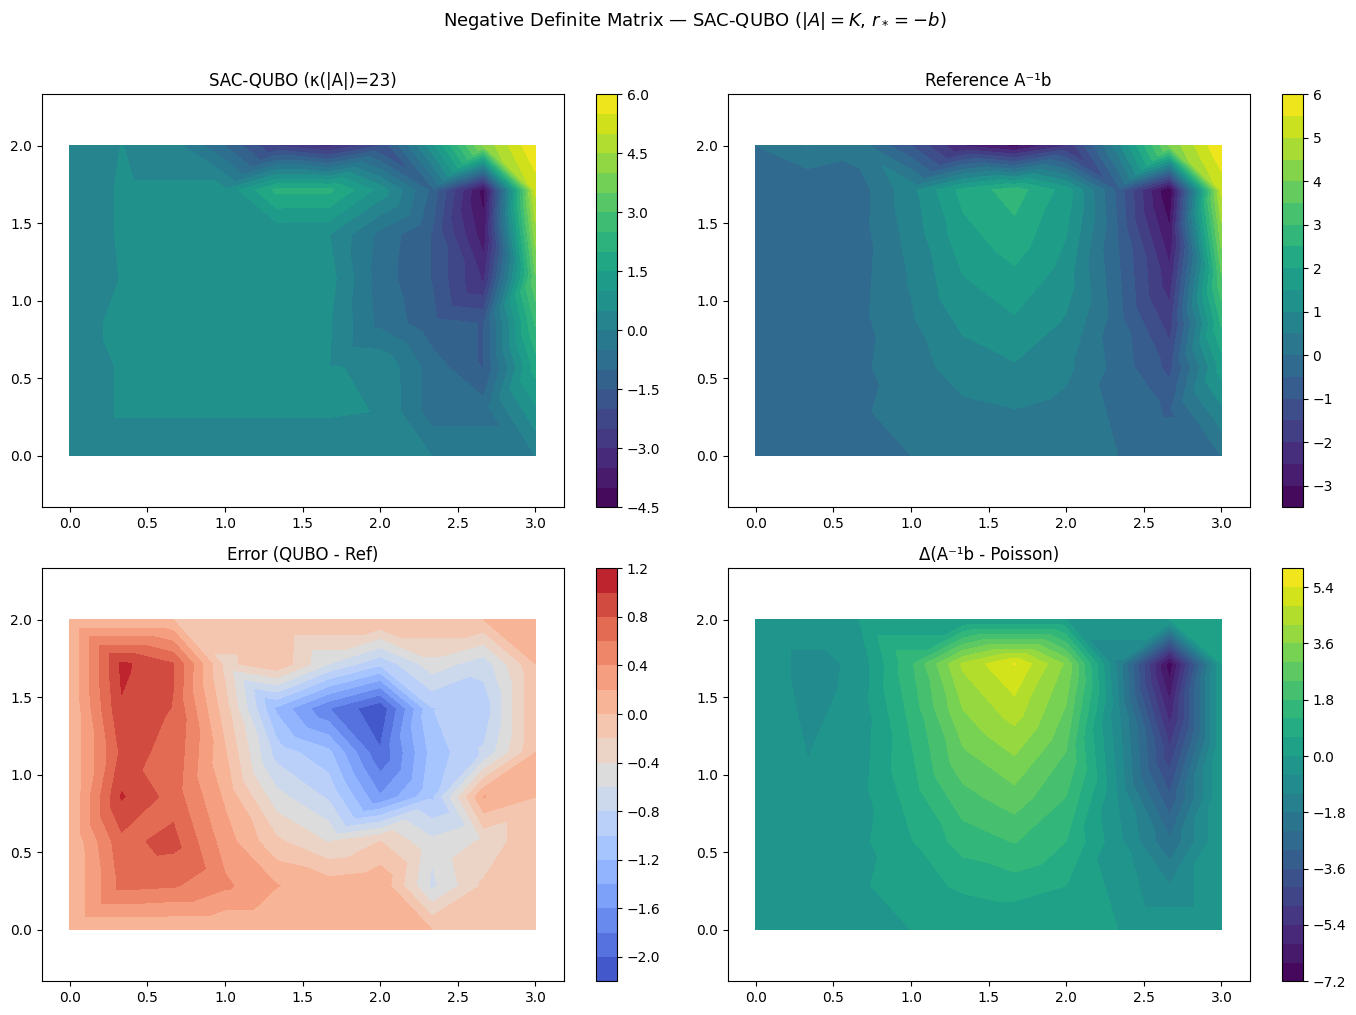

In [20]:
# ===== 可视化 =====
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, data, title in [
    (axes[0,0], u_quantum, f'SAC-QUBO (κ(|A|)={np.linalg.cond(absA):.0f})'),
    (axes[0,1], u_ref_A_all, 'Reference A⁻¹b'),
    (axes[1,0], u_quantum-u_ref_A_all, 'Error (QUBO - Ref)'),
    (axes[1,1], u_ref_A_all-u_exact_all, 'Δ(A⁻¹b - Poisson)')]:
    cmap = 'coolwarm' if 'Error' in title else 'viridis'
    im = ax.tricontourf(nodes[:,0], nodes[:,1], data, levels=20, cmap=cmap)
    ax.set_title(title); ax.axis('equal'); fig.colorbar(im, ax=ax)
fig.suptitle('Negative Definite Matrix — SAC-QUBO ($|A|=K$, $r_*=-b$)', fontsize=13, y=1.01)
plt.tight_layout(); plt.savefig(f'{OUTPUT_DIR}/solution.png', dpi=150, bbox_inches='tight')
plt.show()
